In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.isnull().mean()*100 

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
df.shape

(19158, 13)

In [10]:
#identifying numeric/categorical variables having missing value more than 5%
cols=[var for var in df.columns if df[var].isnull().mean() <0.05 and df[var].isnull().mean()>0]

cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [11]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
5335,0.925,Full time course,Graduate,3.0,228.0
11975,0.926,no_enrollment,Masters,14.0,52.0
12883,0.926,no_enrollment,NaN,10.0,24.0
10597,0.910,no_enrollment,Graduate,20.0,19.0
5389,0.920,Part time course,Graduate,1.0,117.0


In [12]:
df['education_level'].value_counts() #shows all categorical values

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [13]:
len(df[cols].dropna()) / len(df) #shows the percentage of data that will be lost if we drop the missing values in these columns


0.8968577095730244

In [ ]:
#2. Perform Univariate Analysis on the columns having missing values less than 5% and drop the missing values in those columns.
new_df = df[cols].dropna() #creating a new dataframe with only the columns having missing values less than 5% and dropping the missing values in those columns
df.shape, new_df.shape

((19158, 13), (17182, 5))

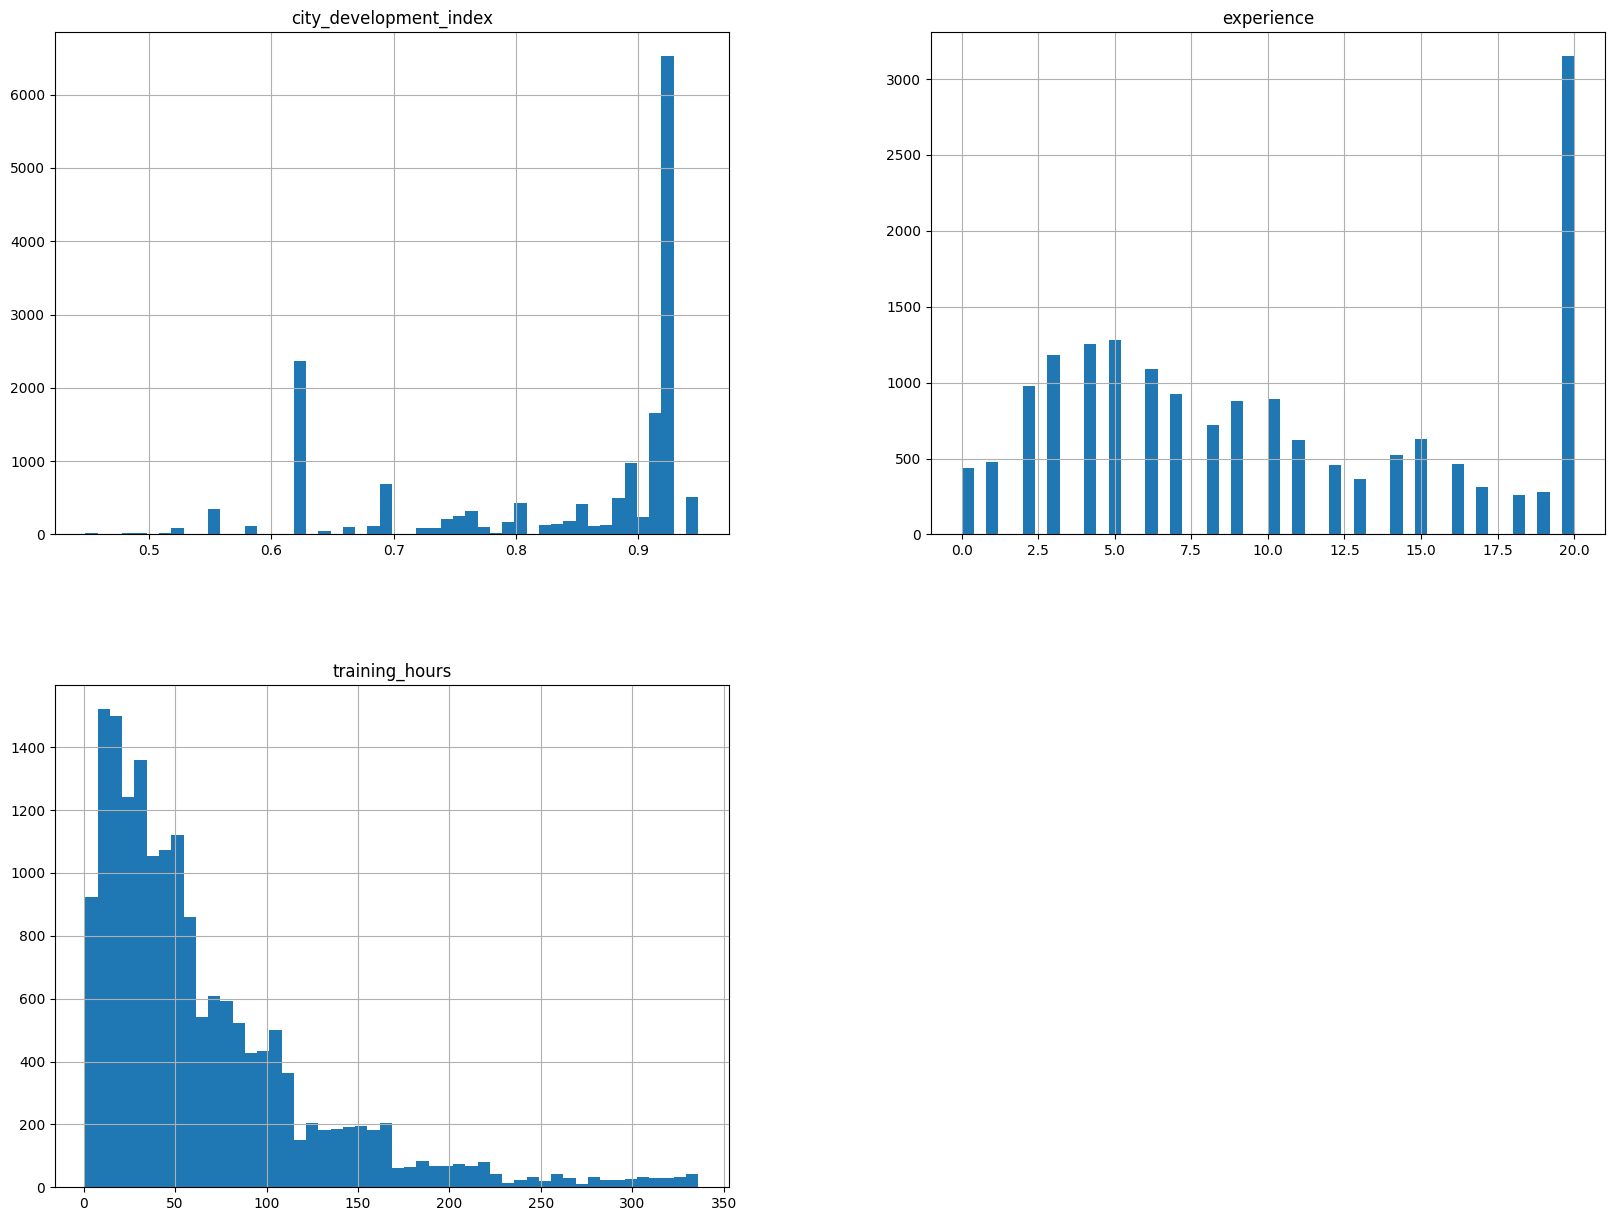

In [17]:
#3. Plot the histograms for the columns having missing values less than 5% and check the distribution of the data.
new_df.hist(bins=50, figsize=(20,15)) #figsize is used to increase the size of the plot
plt.show()

<Axes: >

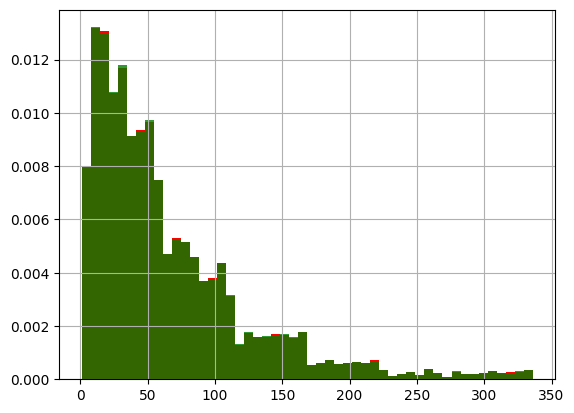

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# 5 data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

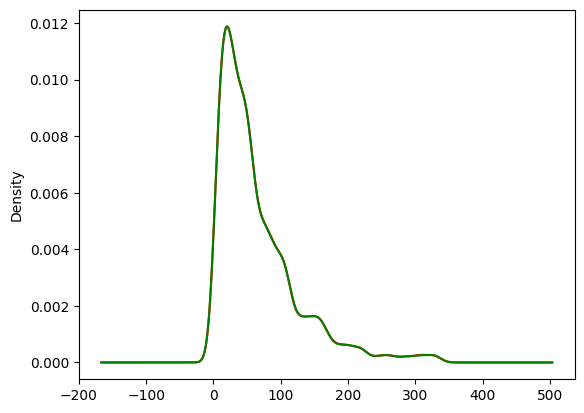

In [19]:
#5 Plot the density plot for the columns having missing values less than 5% and check the distribution of the data.
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: ylabel='Density'>

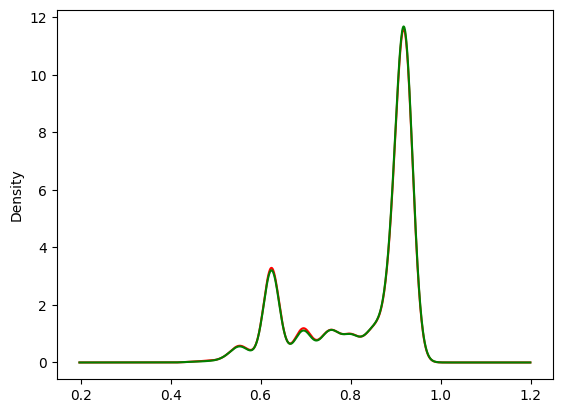

In [22]:
# for each column having missing values less than 5%, we will plot the density plot to check the distribution of the data before and after cca
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: ylabel='Density'>

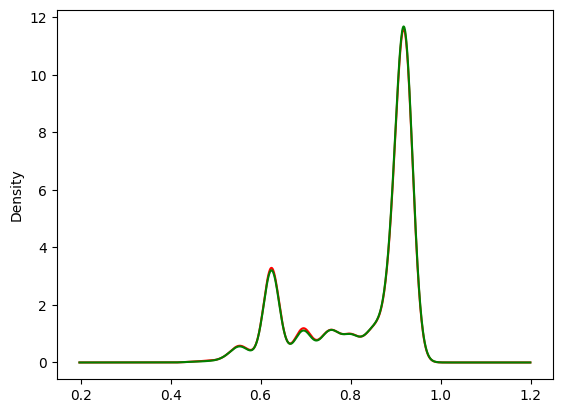

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green') 
# from the density plot we can see that the distribution of the data before and after cca is almost same, so we can say that cca has not affected the distribution of the data.

In [24]:
#6. Compare the percentage of observations per category in the original data and cca data for the columns having missing values less than 5%.
temp = pd.concat([
            # percentage of observations per category, original data
            df['enrolled_university'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['enrolled_university'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [ ]:
#Here we can see that the percentage of observations per category in the original data and cca data for the column 'enrolled_university' is almost same, so we can say that cca has not affected the distribution of the data for this column.
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
